<a href="https://colab.research.google.com/github/Aymane-Elb/ML_Projects/blob/main/Aymane_El_Abdi_Tp2_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pré-traitement des données pour le Machine Learning  
## Notebook pratique complet- avant les algorithmes (régression linéaire, etc.)

**Objectif du notebook**

Ce notebook est pensé pour un TP **avant** d'introduire les algorithmes de Machine Learning.  
L'idée est de faire comprendre **pratiquement** pourquoi le pré-traitement est indispensable.

On va travailler sur :
- la lecture et la compréhension d'un dataset ;
- la différence entre **échantillon**, **feature**, **target** et **ID** ;
- les statistiques de base : min, max, moyenne, médiane, variance, écart-type ;
- la détection des **valeurs manquantes** ;
- la détection des **valeurs aberrantes (outliers)** ;
- la **visualisation** des données ;
- la différence entre **normalisation** et **standardisation** ;
- le lien entre tout cela et les futurs algorithmes de ML.

---

## Pourquoi ce notebook est important ?

Avant de lancer un algorithme, il faut répondre à des questions simples :

1. Est-ce que mes données sont propres ?
2. Est-ce que toutes les colonnes ont du sens pour l'apprentissage ?
3. Est-ce que les variables ont des échelles comparables ?
4. Est-ce qu'il y a des valeurs manquantes ?
5. Est-ce qu'il y a des valeurs extrêmes qui vont perturber le modèle ?
6. Est-ce qu'on risque d'apprendre de **fausses relations** ?

**Idée clé :**  
> Un bon algorithme sur de mauvaises données donne souvent un mauvais résultat.  
> Un modèle de ML n'est pas "intelligent" tout seul : il apprend seulement à partir de ce qu'on lui donne.
---

## Ce que vous pourrez dire aux étudiants

- **Le pré-traitement n'est pas une étape secondaire.**
- **C'est souvent là que se joue la qualité du futur modèle.**
- **Le machine learning commence par comprendre les données, pas par choisir un algorithme.**


In [ ]:
# Librairies de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Pour afficher davantage de colonnes si besoin
pd.set_option("display.max_columns", None)

# 1) Rappel rapide : vocabulaire de base

## a) Échantillon (sample)
Une **ligne** du tableau.  
Exemple : un étudiant, une maison, un client, une transaction.

## b) Feature / attribut / variable explicative
Une **colonne d'entrée** utilisée pour décrire un échantillon.  
Exemples : âge, revenu, nombre d'absences, surface, température.

## c) Target / cible
La variable qu'on veut **prédire** plus tard.  
Exemples :
- une note finale ;
- le prix d'une maison ;
- "admis / non admis" ;
- "fraude / non fraude".

## d) ID
Une colonne d'identification unique : numéro étudiant, matricule, numéro capteur, code client...

⚠️ **Très important :** un ID n'est généralement **pas une vraie feature** pour le ML.  
Pourquoi ? Parce qu'il sert à **identifier**, pas à **expliquer**.

Exemple :
- `Student_ID = 105`
- `Client_ID = 9001`

Le fait qu'un étudiant ait l'ID 105 ne veut pas dire qu'il va réussir ou échouer.

---

## Première règle pratique

> Toutes les colonnes d'un tableau ne doivent pas forcément être données au futur modèle.


# 2) Dataset 1 — Performance d'étudiants

Dans ce premier exercice, on simule un petit dataset d'étudiants.

Nous voulons préparer les données pour une future tâche de ML.  
Pour l'instant, **on ne lance aucun algorithme**.  
On fait seulement le **travail d'analyse et de préparation**.


In [ ]:
# Création d'un dataset jouet pour le cours
df_students = pd.DataFrame({
    "Student_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012],
    "Age":        [18,   19,   20,   21,   20,   22,   19,   23,   21,   20,   24,   19],
    "Study_Hours":[2,    3,    5,    6,    7,    1,    4,    8,    np.nan, 5,   3,    50],
    "Absences":   [12,   10,   7,    4,    3,    15,   8,    2,    6,    np.nan, 9,   1],
    "Sleep_Hours":[5.5,  6.0,  6.5,  7.0,  7.5,  5.0,  6.0,  8.0,  6.5,  6.0,   7.0,  4.5],
    "Final_Score":[45,   50,   62,   70,   78,   40,   58,   88,   65,   60,    55,   92],
    "Internet_Hours":[5, 4.5,  4,     3.5,  3,    6,   5,    3,    5,    1,      2,    20]
})

df_students


,Student_ID,Age,Study_Hours,Absences,Sleep_Hours,Final_Score,Internet_Hours
0,1001,18,2.0,12.0,5.5,45,5.0
1,1002,19,3.0,10.0,6.0,50,4.5
2,1003,20,5.0,7.0,6.5,62,4.0
3,1004,21,6.0,4.0,7.0,70,3.5
4,1005,20,7.0,3.0,7.5,78,3.0
5,1006,22,1.0,15.0,5.0,40,6.0
6,1007,19,4.0,8.0,6.0,58,5.0
7,1008,23,8.0,2.0,8.0,88,3.0
8,1009,21,NaN,6.0,6.5,65,5.0
9,1010,20,5.0,NaN,6.0,60,1.0


## Exercice 1 — Questions

### Questions de compréhension
1. Quelle est la **cible** si, plus tard, on veut prédire la performance finale ?
2. Quelles colonnes sont de vraies **features** ?
3. La colonne `Student_ID` doit-elle être utilisée pour entraîner un modèle ? Pourquoi ?
4. Quelle colonne vous semble immédiatement suspecte ?
5. Y a-t-il des **valeurs manquantes** ?
6. À votre avis, quelles colonnes risquent d'avoir des **outliers** ?

Prenez d'abord 2 minutes pour répondre **sans code**.


## Correction — Lecture intelligente du dataset

- **Target possible :** `Final_Score`
- **Features possibles :** `Age`, `Study_Hours`, `Absences`, `Sleep_Hours`
- **À exclure du ML :** `Student_ID`

### Pourquoi exclure l'ID ?
Parce que :
- il ne représente pas une propriété utile ;
- il ne décrit pas le comportement ou le phénomène ;
- il peut créer une **fausse relation**.

### Exemple de faux apprentissage
Si, par hasard, les derniers étudiants ont de meilleures notes, un modèle peut croire que :
> "plus l'ID est grand, meilleure est la note"

Alors qu'en réalité, l'ID n'a **aucun sens causal**.

👉 **Conclusion pédagogique :**
> Un modèle de ML peut apprendre une relation absurde si on lui donne des colonnes absurdes.


In [ ]:
# Informations globales sur le dataset
print("Dimensions :", df_students.shape)
print("\nTypes des colonnes :")
print(df_students.dtypes)
print("\nInformations générales :")
display(df_students.info())

Dimensions : (12, 7)

Types des colonnes :
Student_ID          int64
Age                 int64
Study_Hours       float64
Absences          float64
Sleep_Hours       float64
Final_Score         int64
Internet_Houre    float64
dtype: object

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      12 non-null     int64  
 1   Age             12 non-null     int64  
 2   Study_Hours     11 non-null     float64
 3   Absences        11 non-null     float64
 4   Sleep_Hours     12 non-null     float64
 5   Final_Score     12 non-null     int64  
 6   Internet_Houre  12 non-null     float64
dtypes: float64(4), int64(3)
memory usage: 804.0 bytes


None

In [ ]:
# Statistiques descriptives
df_students.describe()


,Student_ID,Age,Study_Hours,Absences,Sleep_Hours,Final_Score,Internet_Houre
count,12.000000,12.000000,11.000000,11.000000,12.000000,12.000000,12.000000
mean,1006.500000,20.500000,8.545455,7.000000,6.291667,63.583333,3.500000
std,3.605551,1.783765,13.909447,4.358899,1.010363,16.127099,1.796461
min,1001.000000,18.000000,1.000000,1.000000,4.500000,40.000000,0.000000
25%,1003.750000,19.000000,3.000000,3.500000,5.875000,53.750000,2.750000
50%,1006.500000,20.000000,5.000000,7.000000,6.250000,61.000000,3.750000
75%,1009.250000,21.250000,6.500000,9.500000,7.000000,72.000000,5.000000
max,1012.000000,24.000000,50.000000,15.000000,8.000000,92.000000,6.000000


## Lecture des statistiques

À commenter en classe :

- **Mean (moyenne)** : donne une idée du centre des valeurs.
- **Std (écart-type)** : donne une idée de la dispersion.
- **Min / Max** : utiles pour voir l'étendue.
- **25%, 50%, 75%** : ce sont les quartiles.

### Point important
Regardez la colonne `Study_Hours` :
- la plupart des valeurs sont petites ;
- mais une valeur vaut **50**.

👉 C'est probablement une **valeur aberrante**.  
Un étudiant qui étudie 50 heures dans la même unité que les autres ? Très suspect.


In [ ]:
# Vérification des valeurs manquantes
df_students.isna().sum()


,0
Student_ID,0
Age,0
Study_Hours,1
Absences,1
Sleep_Hours,0
Final_Score,0
Internet_Houre,0


## Question

Quelles colonnes contiennent des valeurs manquantes ?

### Réponse
- `Study_Hours`
- `Absences`

---

## Pourquoi les valeurs manquantes posent problème ?

La plupart des algorithmes de ML classiques n'acceptent pas les `NaN` directement.  
Même avant l'algorithme, les statistiques et visualisations peuvent être faussées.

### Que peut-on faire ?
1. **Supprimer** les lignes concernées  
   → simple, mais on perd des données.
2. **Imputer** les valeurs manquantes  
   → remplacer par la moyenne, la médiane, ou une autre stratégie.
3. **Marquer explicitement** qu'une valeur manque  
   → utile dans certains cas.

### Règle simple à donner
- Pour des données numériques avec outliers : la **médiane** est souvent plus robuste que la moyenne.


In [ ]:
# Imputation simple par la médiane pour ce TP
df_students_clean = df_students.copy()
df_students_clean["Study_Hours"] = df_students_clean["Study_Hours"].fillna(df_students_clean["Study_Hours"].median())
df_students_clean["Absences"] = df_students_clean["Absences"].fillna(df_students_clean["Absences"].median())

df_students_clean


,Student_ID,Age,Study_Hours,Absences,Sleep_Hours,Final_Score,Internet_Hours
0,1001,18,2.0,12.0,5.5,45,5.0
1,1002,19,3.0,10.0,6.0,50,4.5
2,1003,20,5.0,7.0,6.5,62,4.0
3,1004,21,6.0,4.0,7.0,70,3.5
4,1005,20,7.0,3.0,7.5,78,3.0
5,1006,22,1.0,15.0,5.0,40,6.0
6,1007,19,4.0,8.0,6.0,58,5.0
7,1008,23,8.0,2.0,8.0,88,3.0
8,1009,21,5.0,6.0,6.5,65,5.0
9,1010,20,5.0,7.0,6.0,60,1.0


## Pourquoi la médiane ici ?

Parce qu'il y a une valeur extrême dans `Study_Hours`.  
La moyenne serait tirée vers le haut par cette valeur.  
La médiane est plus stable.

---

# 3) Visualisation : comprendre les données avant le ML

Une visualisation simple peut déjà révéler :
- une variable mal distribuée ;
- un outlier ;
- une tendance globale ;
- une erreur de saisie ;
- une relation probable avec la cible.


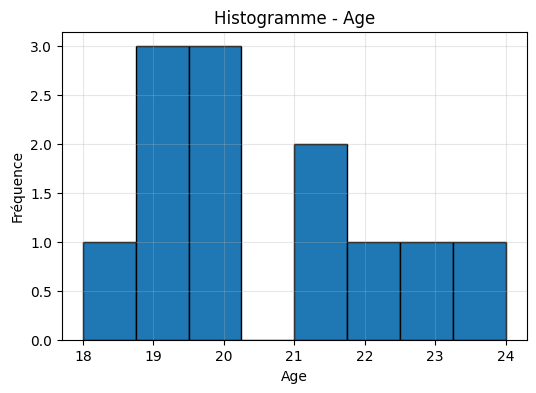

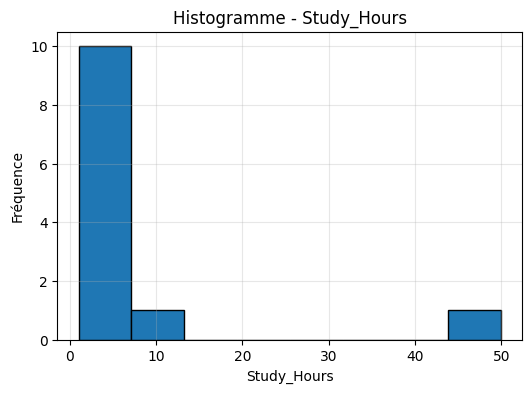

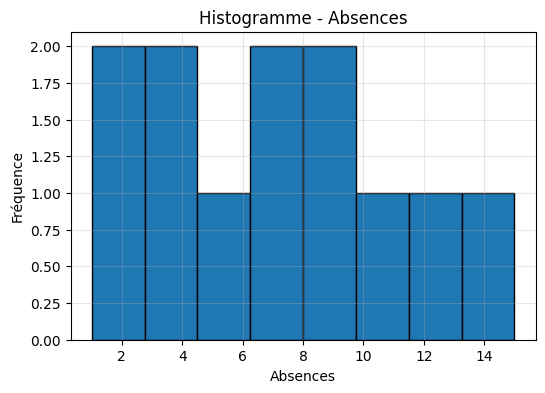

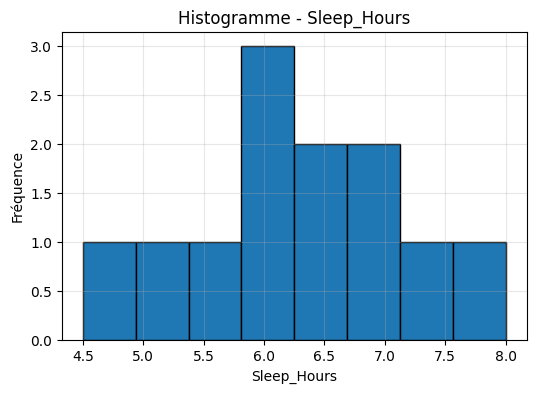

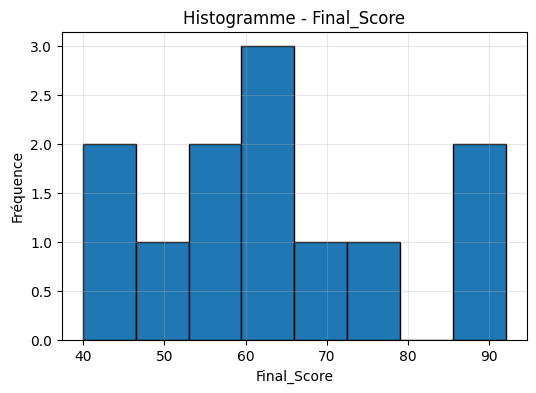

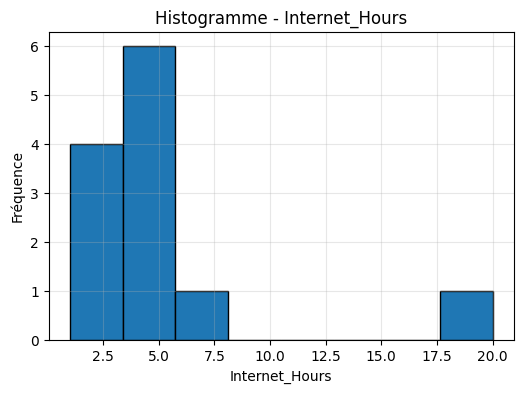

In [ ]:
# Histogrammes des colonnes numériques
num_cols_students = ["Age", "Study_Hours", "Absences", "Sleep_Hours", "Final_Score","Internet_Hours"]
for col in num_cols_students:
    plt.figure(figsize=(6, 4))
    plt.hist(df_students_clean[col], bins=8, edgecolor="black")
    plt.title(f"Histogramme - {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.grid(True, alpha=0.3)
    plt.show()

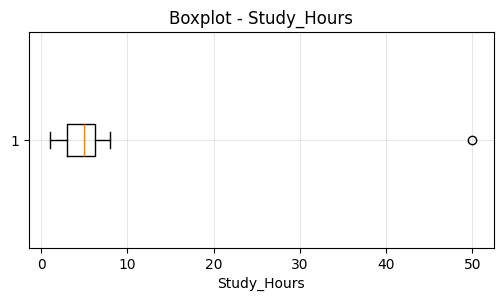

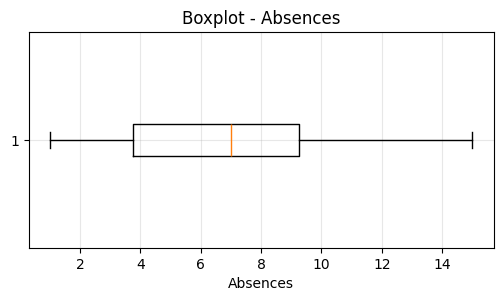

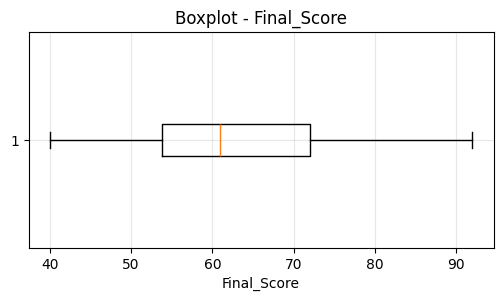

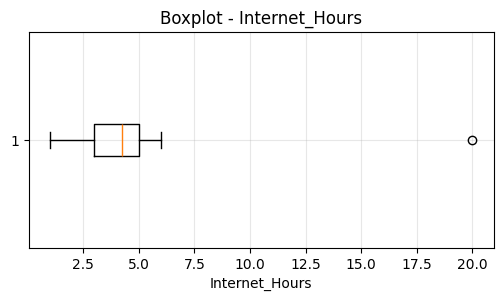

In [ ]:
# Boxplots pour repérer visuellement les outliers
for col in ["Study_Hours", "Absences", "Final_Score","Internet_Hours"]:
    plt.figure(figsize=(6, 2.8))
    plt.boxplot(df_students_clean[col], vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()


## Comment lire un boxplot ?

- La boîte représente la partie centrale des données.
- La ligne au milieu = **médiane**.
- Les "moustaches" montrent l'étendue normale.
- Les points très éloignés peuvent être des **outliers**.

👉 Le boxplot est très utile avant le ML.

---

## Pourquoi la visualisation est utile en ML ?

Parce qu'un tableau brut ne suffit pas toujours.

Exemple :
- une colonne peut sembler normale dans le tableau ;
- mais en graphique, on voit tout de suite qu'une valeur est anormale.

### À retenir
> Visualiser les données, c'est souvent détecter des problèmes avant que le modèle ne les subisse.


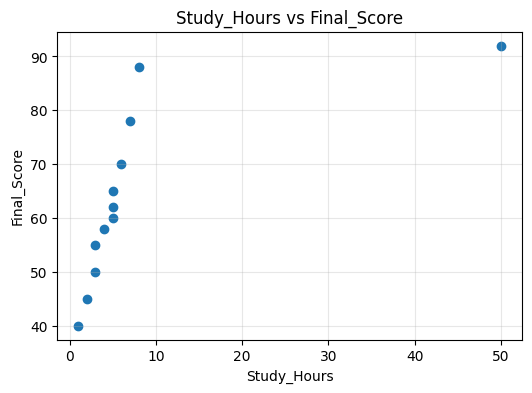

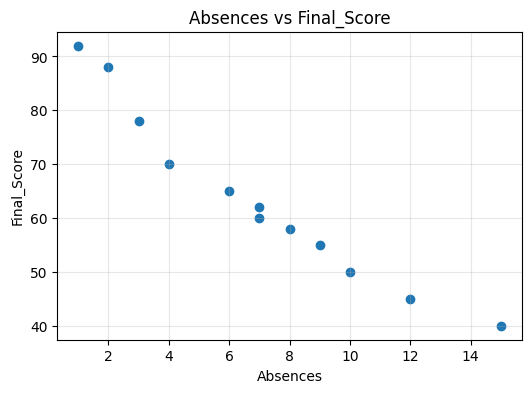

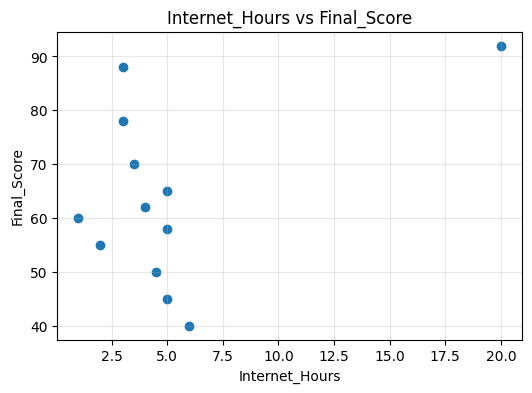

In [ ]:
# Relation entre Study_Hours et Final_Score
plt.figure(figsize=(6, 4))
plt.scatter(df_students_clean["Study_Hours"], df_students_clean["Final_Score"])
plt.title("Study_Hours vs Final_Score")
plt.xlabel("Study_Hours")
plt.ylabel("Final_Score")
plt.grid(True, alpha=0.3)
plt.show()

# Relation entre Absences et Final_Score
plt.figure(figsize=(6, 4))
plt.scatter(df_students_clean["Absences"], df_students_clean["Final_Score"])
plt.title("Absences vs Final_Score")
plt.xlabel("Absences")
plt.ylabel("Final_Score")
plt.grid(True, alpha=0.3)
plt.show()

# Relation entre Internet_Hours et le Final_Score
plt.figure(figsize=(6, 4))
plt.scatter(df_students_clean["Internet_Hours"], df_students_clean["Final_Score"])
plt.title("Internet_Hours vs Final_Score")
plt.xlabel("Internet_Hours")
plt.ylabel("Final_Score")
plt.grid(True, alpha=0.3)
plt.show()


## Interprétation à faire avec les étudiants

- Plus un étudiant étudie, plus son score semble augmenter... **sauf peut-être une anomalie**.
- Plus les absences augmentent, plus le score semble baisser.
- Plus l'Internet_Hours augument, plus son score semble a baiser... sauf peut-être une anomalie.

⚠️ Mais attention :
- ce n'est qu'une **observation visuelle** ;
- ce n'est pas encore une preuve statistique ;
- et ce n'est pas encore un modèle.

---

# 4) Détection simple des outliers avec l'IQR

Rappel :
- `Q1` = 1er quartile
- `Q3` = 3e quartile
- `IQR = Q3 - Q1`

Règle classique :
- borne basse = `Q1 - 1.5 × IQR`
- borne haute = `Q3 + 1.5 × IQR`

Les valeurs en dehors peuvent être considérées comme aberrantes.


In [ ]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return q1, q3, iqr, lower, upper, outliers

for col in ["Study_Hours", "Absences","Internet_Hours", "Final_Score"]:
    q1, q3, iqr, lower, upper, outliers = detect_outliers_iqr(df_students_clean[col])
    print(f"--- {col} ---")
    print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
    print(f"Borne basse = {lower:.2f}, borne haute = {upper:.2f}")
    print("Outliers détectés :", list(outliers.values))
    print()

--- Study_Hours ---
Q1 = 3.00, Q3 = 6.25, IQR = 3.25
Borne basse = -1.88, borne haute = 11.12
Outliers détectés : [np.float64(50.0)]

--- Absences ---
Q1 = 3.75, Q3 = 9.25, IQR = 5.50
Borne basse = -4.50, borne haute = 17.50
Outliers détectés : []

--- Internet_Hours ---
Q1 = 3.00, Q3 = 5.00, IQR = 2.00
Borne basse = 0.00, borne haute = 8.00
Outliers détectés : [np.float64(20.0)]

--- Final_Score ---
Q1 = 53.75, Q3 = 72.00, IQR = 18.25
Borne basse = 26.38, borne haute = 99.38
Outliers détectés : []



## Question

Faut-il toujours supprimer un outlier ?

### Réponse : non.

Un outlier peut être :
1. une **erreur** (saisie, mesure, unité) ;
2. une **vraie valeur rare** mais importante ;
3. un signal métier intéressant.

### Décision pratique
- Si c'est une erreur évidente → corriger ou supprimer.
- Si c'est une vraie observation rare → attention avant de la supprimer.

### Exemple
- Température de 2000°C dans une salle de classe → probablement erreur.
- Transaction bancaire très élevée → peut indiquer une fraude, donc information utile.


# 5) Normalisation vs Standardisation

C'est souvent le point qui crée le plus de confusion.

---

## A) Normalisation Min-Max

Formule :

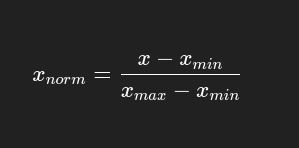

### Effet
- ramène les valeurs dans un intervalle, souvent **[0,1]** ;
- utile quand on veut des valeurs comparables et bornées.

### Avantage
- facile à comprendre ;
- pratique pour des données naturellement bornées (ex: pixels, scores, pourcentages).

### Limite
- très sensible aux **min** et **max** ;
- donc très sensible aux **outliers**.

---

## B) Standardisation Z-score

Formule :

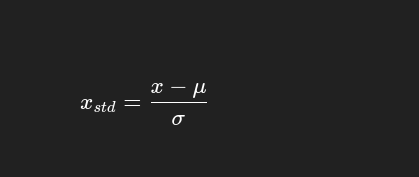

avec :
- \(\mu\) = moyenne ;
- \(\sigma\) = écart-type.

### Effet
- recentre les données autour de **0** ;
- donne un écart-type proche de **1**.

### Avantage
- souvent un bon choix général ;
- utile pour plusieurs algorithmes sensibles à l'échelle.

### Limite
- les valeurs ne sont pas bornées entre 0 et 1 ;
- reste influencée par les outliers, même si souvent moins "écrasante" que Min-Max.


In [ ]:
# Fonctions simples sans bibliothèque externe
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

def z_score_scale(series):
    return (series - series.mean()) / series.std(ddof=0)

scaled_compare = pd.DataFrame({
    "Original_Study_Hours": df_students_clean["Study_Hours"],
    "MinMax_Study_Hours": min_max_scale(df_students_clean["Study_Hours"]),
    "Zscore_Study_Hours": z_score_scale(df_students_clean["Study_Hours"]),
    "Original_Absences": df_students_clean["Absences"],
    "MinMax_Absences": min_max_scale(df_students_clean["Absences"]),
    "Zscore_Absences": z_score_scale(df_students_clean["Absences"]),
    "MinMax_Internet_Hours": min_max_scale(df_students_clean["Internet_Hours"]),
    "Zscore_Internet_Hours": z_score_scale(df_students_clean["Internet_Hours"])
})

scaled_compare.round(3)


,Original_Study_Hours,MinMax_Study_Hours,Zscore_Study_Hours,Original_Absences,MinMax_Absences,Zscore_Absences,MinMax_Internet_Hours,Zscore_Internet_Hours
0,2.0,0.020,-0.491,12.0,0.786,1.257,0.211,-0.036
1,3.0,0.041,-0.412,10.0,0.643,0.754,0.184,-0.143
2,5.0,0.082,-0.255,7.0,0.429,0.000,0.158,-0.250
3,6.0,0.102,-0.177,4.0,0.214,-0.754,0.132,-0.357
4,7.0,0.122,-0.098,3.0,0.143,-1.005,0.105,-0.464
5,1.0,0.000,-0.569,15.0,1.000,2.010,0.263,0.178
6,4.0,0.061,-0.334,8.0,0.500,0.251,0.211,-0.036
7,8.0,0.143,-0.020,2.0,0.071,-1.257,0.105,-0.464
8,5.0,0.082,-0.255,6.0,0.357,-0.251,0.211,-0.036
9,5.0,0.082,-0.255,7.0,0.429,0.000,0.000,-0.891


## Commenter ce tableau en classe

Regardez `Study_Hours` :

- Avec **Min-Max**, la valeur 50 devient **1.0** et les autres valeurs sont compressées près de 0.
- Avec **Z-score**, la valeur 50 reste très grande en valeur standardisée, mais les autres valeurs sont moins écrasées.

==> Cela montre que **Min-Max est très sensible aux valeurs extrêmes**.

---

## Résumé pratique : quand utiliser quoi ?

### Utiliser plutôt la normalisation Min-Max si :
- on veut des valeurs entre **0 et 1** ;
- les données ont des bornes naturelles ;
- on travaille avec des pixels ou proportions ;
- on veut préparer des données pour certains modèles sensibles aux plages de valeurs.

### Utiliser plutôt la standardisation si :
- on prépare des données pour la **régression linéaire**, la **régression logistique**, les **SVM**, la **PCA**, les méthodes à base de **gradient** ;
- les variables ont des unités très différentes ;
- on veut une méthode souvent plus adaptée comme **choix par défaut**.

### Ne pas oublier :
- s'il y a beaucoup d'outliers, parfois **aucune des deux** n'est idéale ;
- dans ce cas, on peut penser à des méthodes robustes (basées sur médiane/IQR).

---

## Phrase simple à retenir

> La normalisation change l'intervalle.  
> La standardisation change le centre et l'échelle.


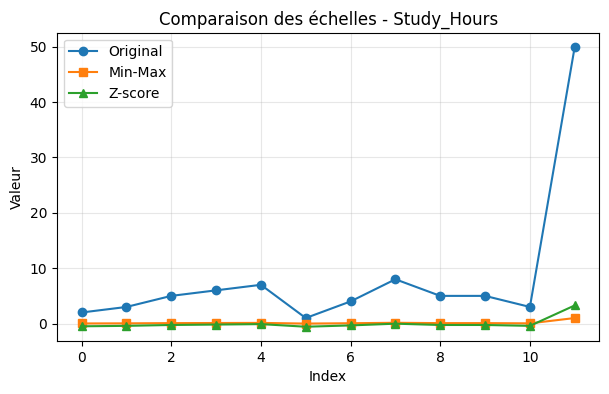

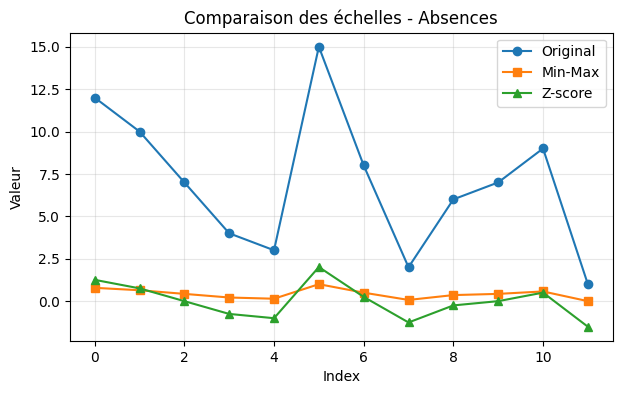

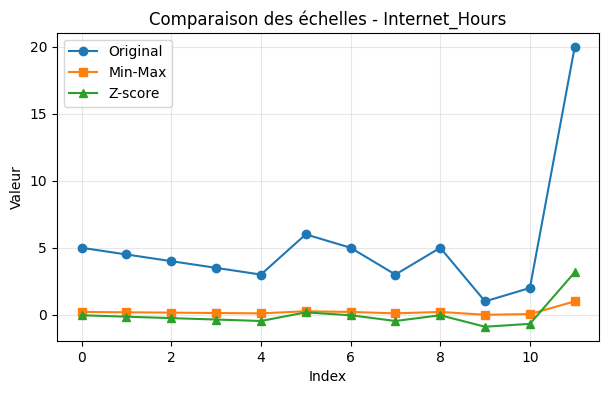

In [ ]:
# Comparaison visuelle entre original / normalisé / standardisé
figures = [
    ("Study_Hours", df_students_clean["Study_Hours"], min_max_scale(df_students_clean["Study_Hours"]), z_score_scale(df_students_clean["Study_Hours"])),
    ("Absences", df_students_clean["Absences"], min_max_scale(df_students_clean["Absences"]), z_score_scale(df_students_clean["Absences"])),
    ("Internet_Hours", df_students_clean["Internet_Hours"], min_max_scale(df_students_clean["Internet_Hours"]), z_score_scale(df_students_clean["Internet_Hours"]))
]
for name, original, mm, zs in figures:
    plt.figure(figsize=(7, 4))
    plt.plot(original.values, marker="o", label="Original")
    plt.plot(mm.values, marker="s", label="Min-Max")
    plt.plot(zs.values, marker="^", label="Z-score")
    plt.title(f"Comparaison des échelles - {name}")
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Point très important pour le futur ML

Quand on mettra en place des algorithmes, il faudra faire attention à **ne pas calculer la normalisation sur tout le dataset avant la séparation train/test**.

### Pourquoi ?
Parce que cela crée une **fuite d'information (data leakage)**.

### Bonne pratique
1. Séparer **train** et **test**
2. Calculer min/max ou mean/std **sur le train seulement**
3. Appliquer cette transformation au test

👉 Même si vous ne faites pas encore les algorithmes aujourd'hui, cette règle doit déjà être annoncée aux étudiants.


# 6) Pourquoi le pré-traitement est nécessaire pour les futurs algorithmes de ML ?

Même si on ne les utilise pas encore, voici ce qui se passera plus tard.

---

## a) Régression linéaire
La régression linéaire essaie d'ajuster une relation entre les variables d'entrée et la cible.

### Pourquoi le pré-traitement aide ?
- des valeurs manquantes bloquent souvent l'apprentissage ;
- des outliers peuvent tirer la droite de régression ;
- des colonnes inutiles comme l'ID peuvent créer des relations absurdes ;
- des variables très mal échelonnées peuvent compliquer l'optimisation et l'interprétation.

---

## b) KNN (k plus proches voisins)
Cet algorithme repose sur les **distances**.

### Problème
Si une variable est beaucoup plus grande numériquement qu'une autre, elle domine tout.

Exemple :
- âge entre 18 et 25 ;
- salaire entre 2000 et 10000.

Sans normalisation, le salaire écrase l'âge dans le calcul de distance.

---

## c) K-means
K-means repose aussi sur la distance.

Même problème :
- une variable à grande échelle attire le clustering à elle seule.

---

## d) Réseaux de neurones / optimisation par gradient
Des échelles très différentes peuvent rendre l'apprentissage moins stable ou plus lent.

---

## e) PCA et méthodes géométriques
Ces méthodes sont très sensibles à l'échelle des variables.

---

## Conclusion

> Le pré-traitement prépare le terrain pour que l'algorithme apprenne quelque chose de pertinent.


# 7) Mini démonstration simple : pourquoi l'échelle change les distances ?

On prend deux variables :
- `Age` : petite échelle
- `Revenu` : grande échelle

On calcule des distances avant et après mise à l'échelle.


In [ ]:
distance_df = pd.DataFrame({
    "Age": [20, 22, 24],
    "Income": [2000, 7000, 9000]
}, index=["A", "B", "C"])

distance_df


In [ ]:
def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Distances avant normalisation
AB_before = euclidean(distance_df.loc["A"], distance_df.loc["B"])
AC_before = euclidean(distance_df.loc["A"], distance_df.loc["C"])

scaled_distance_df = distance_df.copy()
for col in scaled_distance_df.columns:
    scaled_distance_df[col] = min_max_scale(scaled_distance_df[col])

AB_after = euclidean(scaled_distance_df.loc["A"], scaled_distance_df.loc["B"])
AC_after = euclidean(scaled_distance_df.loc["A"], scaled_distance_df.loc["C"])

print("Distances avant normalisation :")
print("A-B =", round(AB_before, 3))
print("A-C =", round(AC_before, 3))

print("\nDistances après normalisation Min-Max :")
print("A-B =", round(AB_after, 3))
print("A-C =", round(AC_after, 3))

print("\nDataset normalisé :")
display(scaled_distance_df)


## Interprétation

Avant normalisation, la colonne `Income` domine presque toute la distance.  
Après normalisation, `Age` et `Income` participent tous les deux de façon comparable.

👉 C'est exactement pour cela que la mise à l'échelle est cruciale pour les algorithmes basés sur la distance.

---

# 8) Exercice pratique complet n°1 — correction guidée


## Énoncé — Exercice 1 : Préparation d'un dataset étudiant

À partir du dataset `df_students`, répondre aux questions suivantes :

1. Quelle est la cible ?
2. Quelles colonnes doivent être exclues du futur modèle ?
3. Quelles colonnes contiennent des valeurs manquantes ?
4. Proposer une stratégie d'imputation et la justifier.
5. Repérer au moins une valeur aberrante.
6. Visualiser les distributions importantes.
7. Comparer la normalisation et la standardisation sur `Study_Hours` et `Absences`.
8. Dire quelle transformation vous choisiriez avant une future **régression linéaire**, et pourquoi.


## Correction: Exercice 1

### 1. Cible
`Final_Score`

### 2. Colonne à exclure
`Student_ID`

### 3. Valeurs manquantes
- `Study_Hours`
- `Absences`

### 4. Imputation proposée
Utiliser la **médiane** :
- plus robuste en présence de valeurs extrêmes ;
- évite qu'un outlier tire la valeur de remplacement.

### 5. Valeur aberrante
`Study_Hours = 50` semble anormale par rapport aux autres.

### 6. Visualisations utiles
- histogrammes ;
- boxplots ;
- nuages de points avec la cible.

### 7. Comparaison des transformations
- Min-Max : pratique mais fortement affectée par le 50 ;
- Z-score : plus adaptée comme préparation générale.

### 8. Choix pour une future régression linéaire
**Standardisation** souvent préférable :
- les variables sont centrées ;
- les échelles deviennent comparables ;
- utile pour l'optimisation et la comparaison des coefficients (selon le contexte).


# 9) Dataset 2 — Loyers d'appartements (préparation pour une future régression)

Ici, la cible sera clairement **numérique** : `Rent`.

Ce dataset prépare bien la transition vers la **régression linéaire** de la prochaine séance.


In [ ]:
df_rent = pd.DataFrame({
    "Flat_ID": [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512],
    "Area_m2": [45, 60, 75, 52, 90, 110, 85, 40, 70, 65, 95, 300],
    "Rooms": [2, 3, 3, 2, 4, 5, 4, 1, 3, 3, 4, 8],
    "Distance_Center_km": [8, 6, 5, 9, 4, 3, np.nan, 12, 7, 6, 2, 1],
    "Building_Age": [20, 15, 10, 30, 8, 5, 12, 40, 18, 14, 6, 2],
    "Rent": [2500, 3200, 3900, 2700, 5000, 6200, 4700, 2000, 3600, 3400, 5400, 18000]
})

df_rent


## Exercice 2 — Questions

1. Quelle est la cible ?

 la cible c'est le Rent

2. Quelle colonne ne doit pas être utilisée pour le futur modèle ?
Flat_ID

3. Quelle colonne contient une valeur manquante ?
 Distance_Center_km
4. Quelle ligne semble contenir un outlier ?
 Area_m2
5. Quelles relations visuelles semble-t-on observer entre :
   - `Area_m2` et `Rent` Corrolation positif (linére) si le area_m2 augument le rent augument aussi  
   - `Distance_Center_km` et `Rent` corrolation negatif (lineaire) si la distance au centre augment le prix diminue
6. Que faut-il faire avant d'entraîner plus tard une régression linéaire ?
 supprimer les valures null + visualisation + la normalisation ou standardisation

In [ ]:
print("Valeurs manquantes :")
display(df_rent.isna().sum())
print("\nStatistiques descriptives :")
display(df_rent.describe())

In [ ]:
# Imputation simple de Distance_Center_km par la médiane
df_rent_clean = df_rent.copy()
df_rent_clean["Distance_Center_km"] = df_rent_clean["Distance_Center_km"].fillna(df_rent_clean["Distance_Center_km"].median())

df_rent_clean


In [ ]:
# Visualisations
pairs = [("Area_m2", "Rent"), ("Distance_Center_km", "Rent"), ("Building_Age", "Rent")]
for x_col, y_col in pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_rent_clean[x_col], df_rent_clean[y_col])
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# Boxplots pour repérer les valeurs extrêmes
for col in ["Area_m2", "Rent", "Distance_Center_km"]:
    plt.figure(figsize=(6, 2.8))
    plt.boxplot(df_rent_clean[col], vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

## Correction attendue — Exercice 2

### 1. Cible
`Rent`

### 2. Colonne à exclure
`Flat_ID`

### 3. Valeur manquante
`Distance_Center_km`

### 4. Outlier probable
Le dernier appartement :
- `Area_m2 = 300`
- `Rent = 18000`

Ce n'est pas forcément faux, mais c'est très éloigné des autres.

### 5. Relations visuelles probables
- plus la surface augmente, plus le loyer augmente ;
- plus la distance au centre augmente, plus le loyer a tendance à baisser.

### 6. Avant une future régression linéaire
- retirer l'ID ;
- traiter les valeurs manquantes ;
- examiner les outliers ;
- éventuellement standardiser les variables d'entrée ;
- séparer train/test avant d'ajuster le scaler.


# 10) Comparaison pratique sur le dataset des loyers

On compare maintenant les versions originales, normalisées et standardisées de quelques colonnes.


In [ ]:
rent_compare = pd.DataFrame({
    "Area_m2": df_rent_clean["Area_m2"],
    "Area_m2_minmax": min_max_scale(df_rent_clean["Area_m2"]),
    "Area_m2_zscore": z_score_scale(df_rent_clean["Area_m2"]),
    "Distance_km": df_rent_clean["Distance_Center_km"],
    "Distance_km_minmax": min_max_scale(df_rent_clean["Distance_Center_km"]),
    "Distance_km_zscore": z_score_scale(df_rent_clean["Distance_Center_km"])
})

rent_compare.round(3)


## Question de réflexion

Sur `Area_m2`, pourquoi Min-Max peut devenir problématique si on garde un très grand appartement atypique ?

### Réponse
Parce que ce très grand appartement devient le **max**.  
Du coup, les autres surfaces sont "compressées" dans une petite partie de l'intervalle [0,1].

👉 Cela peut réduire la lisibilité relative des autres observations.

---

# 11) Tableau de synthèse : normalisation ou standardisation ?


In [ ]:
summary = pd.DataFrame({
    "Critère": [
        "Formule",
        "Résultat",
        "Intervalle borné",
        "Sensibilité aux outliers",
        "Quand l'utiliser ?",
        "Exemples classiques",
        "Piège fréquent"
    ],
    "Normalisation Min-Max": [
        "(x - min) / (max - min)",
        "Valeurs ramenées souvent dans [0,1]",
        "Oui",
        "Élevée",
        "Quand on veut une plage fixe ou des valeurs bornées",
        "Pixels, proportions, méthodes à distance (souvent)",
        "Un outlier écrase le reste"
    ],
    "Standardisation Z-score": [
        "(x - moyenne) / écart-type",
        "Moyenne proche de 0, écart-type proche de 1",
        "Non",
        "Présente, mais souvent moins écrasante que Min-Max",
        "Bon choix général avant plusieurs modèles",
        "Régression, SVM, PCA, optimisation",
        "Ne pas l'ajuster sur tout le dataset avant train/test"
    ]
})

summary


,Critère,Normalisation Min-Max,Standardisation Z-score
0,Formule,(x - min) / (max - min),(x - moyenne) / écart-type
1,Résultat,"Valeurs ramenées souvent dans [0,1]","Moyenne proche de 0, écart-type proche de 1"
2,Intervalle borné,Oui,Non
3,Sensibilité aux outliers,Élevée,"Présente, mais souvent moins écrasante que Min..."
4,Quand l'utiliser ?,Quand on veut une plage fixe ou des valeurs bo...,Bon choix général avant plusieurs modèles
5,Exemples classiques,"Pixels, proportions, méthodes à distance (souv...","Régression, SVM, PCA, optimisation"
6,Piège fréquent,Un outlier écrase le reste,Ne pas l'ajuster sur tout le dataset avant tra...


# 12) D'autre questions théoriques

Voici une banque de questions prêtes à l'emploi.

## Questions courtes
1. Qu'est-ce qu'un sample ?
2. Qu'est-ce qu'une feature ?
3. Qu'est-ce qu'une target ?
4. Pourquoi un ID ne doit-il pas être utilisé comme variable d'entrée ?
5. Pourquoi les valeurs manquantes posent-elles problème ?
6. Pourquoi visualiser les données avant le ML ?
7. Quelle différence entre moyenne et médiane ?
8. Pourquoi la médiane est-elle plus robuste ?
9. Quelle différence entre normalisation et standardisation ?
10. Pourquoi faut-il éviter la data leakage ?

## Questions de réflexion
1. Une valeur extrême doit-elle toujours être supprimée ?
2. Peut-on normaliser une colonne catégorielle ?
3. Peut-on standardiser un identifiant ?
4. Pourquoi la mise à l'échelle est-elle importante pour KNN ?
5. Pourquoi les outliers peuvent-ils perturber la régression linéaire ?


# 13) Réponses synthétiques aux questions théoriques

1. **Sample** : une ligne du dataset.  
2. **Feature** : une variable d'entrée.  
3. **Target** : la variable à prédire.  
4. **ID** : il identifie mais n'explique pas.  
5. **Valeurs manquantes** : plusieurs modèles ne les supportent pas.  
6. **Visualiser** : permet de repérer anomalies, tendances, distributions.  
7. **Moyenne vs médiane** : la moyenne est sensible aux extrêmes, la médiane est plus robuste.  
8. **Médiane robuste** : elle n'est pas fortement tirée par une très grande valeur.  
9. **Normalisation vs standardisation** : l'une fixe l'intervalle, l'autre centre et réduit.  
10. **Data leakage** : fuite d'information du test vers l'entraînement.


# 14) Ce qu'il faudra dire au début du prochain cours (régression linéaire)

Vous pouvez faire la transition avec une phrase comme :

> "Maintenant que les données sont comprises, nettoyées, visualisées et mises à l'échelle si nécessaire, on peut enfin apprendre une relation entre les entrées et une cible numérique. C'est exactement ce que fait la régression linéaire."

---

## Lien direct avec la régression linéaire

La régression linéaire va chercher une relation du type :

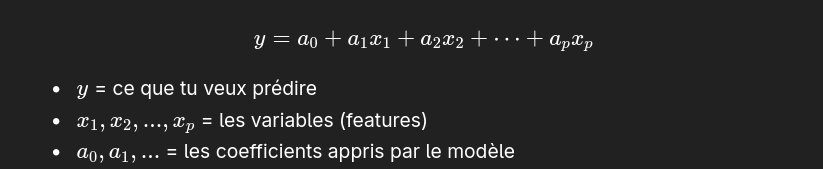

Mais avant de calculer cette relation, il faut que :
- les bonnes colonnes soient choisies ;
- l'ID soit retiré ;
- les valeurs manquantes soient traitées ;
- les outliers soient examinés ;
- les variables aient une échelle cohérente si nécessaire.

👉 Donc le pré-traitement n'est pas "à côté" de la régression.  
👉 Il est ce qui permet à la régression de travailler correctement.


# 15) Petit mémo final

## À retenir absolument

- Comprendre les données avant de modéliser.
- Ne pas confondre **ID** et **feature**.
- Repérer les **valeurs manquantes**.
- Repérer les **outliers**.
- Visualiser avant de conclure.
- Choisir entre **normalisation** et **standardisation** selon le contexte.
- Éviter la **data leakage**.
- Le ML commence par la qualité des données.

---

## Message pédagogique final

> Le rôle du pré-traitement est de rendre les données utilisables, comparables et fiables avant l'apprentissage.


# 16) Travail personnel proposé aux étudiants

À faire à la maison ou en autonomie :

1. Modifier le dataset des étudiants en ajoutant une colonne `Internet_Hours`.
2. Créer un nouvel outlier volontaire.
3. Observer l'effet sur :
   - la moyenne ;
   - la médiane ;
   - la normalisation ;
   - la standardisation.
4. Expliquer dans un paragraphe :
   - quelle méthode est la plus impactée ;
   la standardisation
   - pourquoi.

   car il ya un outliers si on utilise la normalisation sa valeur va nous donnez 1 qui écrase le reste

---

## Défi bonus
Créer un mini dataset personnel de 8 lignes et 5 colonnes, puis :
- définir la cible ;
- identifier les colonnes inutiles ;
- détecter les outliers ;
- comparer Min-Max et Z-score.


In [ ]:
data = {
    "Trade_ID": [1, 2, 3, 4, 5, 6, 7, 8],
    "Prix_Entree": [100, 105, 102, 110, 108, 107, 115, 103],
    "Prix_Sortie": [105, 103, 108, 120, 100, 112, 130, 101],
    "Volume": [1000, 1500, 1200, 2000, 1800, 1600, 2500, 1100],
    "Duree_Min": [30, 45, 20, 60, 50, 40, 90, 25],
    "Profit":[5, -2, 6, 10, -8, 5, 15, -2]
}

df = pd.DataFrame(data)
df.head()
# 1) le Cible cest le profit
# 2) le column inutile est le Trade_Id
# 3) prix de Sortie 120


,Trade_ID,Prix_Entree,Prix_Sortie,Volume,Duree_Min,Profit
0,1,100,105,1000,30,5
1,2,105,103,1500,45,-2
2,3,102,108,1200,20,6
3,4,110,120,2000,60,10
4,5,108,100,1800,50,-8


In [ ]:
def min_max_scale(df):
    return (df - df.min()) / (df.max() - df.min())

def z_score_scale(df):
    return (df - df.mean()) / df.std(ddof=0)


Comparaison_df = pd.DataFrame({
    "Original_Prix_Entree": df["Prix_Entree"],
    "MinMax_Prix_Entree": min_max_scale(df["Prix_Entree"]),
    "Zscore_Prix_Entree": z_score_scale(df["Prix_Entree"]),
    "Original_Prix_Sortie": df["Prix_Sortie"],
    "MinMax_Prix_Sortie": min_max_scale(df["Prix_Sortie"]),
    "Zscore_Prix_Sortie": z_score_scale(df["Prix_Sortie"]),
    "Original_Duree_Min": df["Duree_Min"],
    "MinMax_Duree_Min": min_max_scale(df["Duree_Min"]),
    "Zscore_Duree_Min": z_score_scale(df["Duree_Min"])
})
Comparaison_df= Comparaison_df.round(2)
Comparaison_df.head()


,Original_Prix_Entree,MinMax_Prix_Entree,Zscore_Prix_Entree,Original_Prix_Sortie,MinMax_Prix_Sortie,Zscore_Prix_Sortie,Original_Duree_Min,MinMax_Duree_Min,Zscore_Duree_Min
0,100,0.00,-1.38,105,0.17,-0.50,30,0.14,-0.71
1,105,0.33,-0.28,103,0.10,-0.70,45,0.36,0.00
2,102,0.13,-0.94,108,0.27,-0.19,20,0.00,-1.19
3,110,0.67,0.83,120,0.67,1.04,60,0.57,0.71
4,108,0.53,0.39,100,0.00,-1.01,50,0.43,0.24


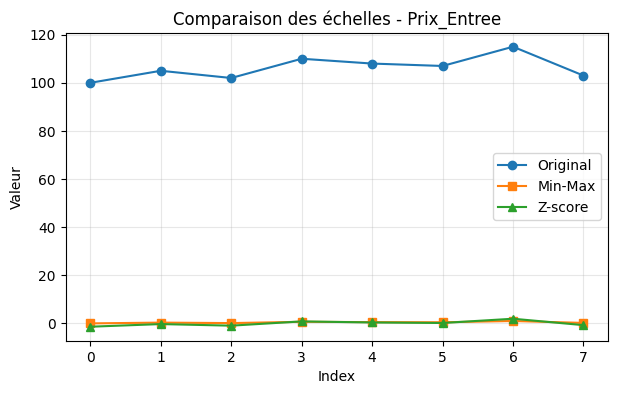

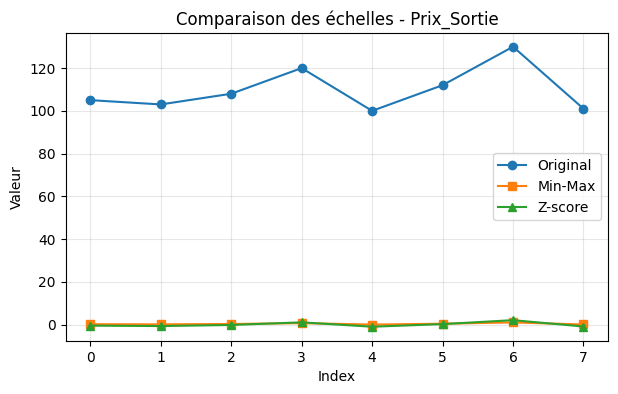

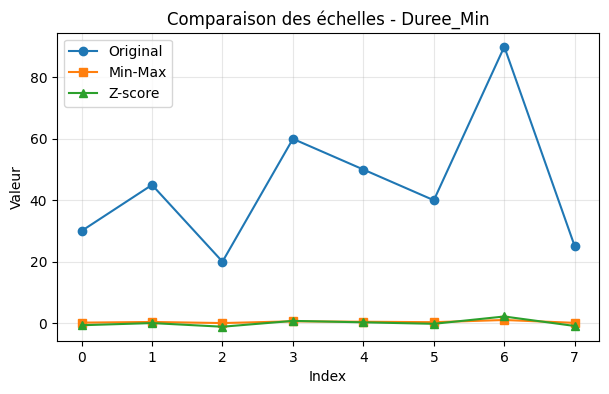

In [ ]:
# Comparaison visuelle entre original / normalisé / standardisé
figures = [
    ("Prix_Entree", df["Prix_Entree"],Comparaison_df["MinMax_Prix_Entree"], Comparaison_df["Zscore_Prix_Entree"]),
    ("Prix_Sortie", df["Prix_Sortie"],Comparaison_df["MinMax_Prix_Sortie"], Comparaison_df["Zscore_Prix_Sortie"]),
    ("Duree_Min", df["Duree_Min"],Comparaison_df["MinMax_Duree_Min"], Comparaison_df["Zscore_Duree_Min"])
]
for name, original, mm, zs in figures:
    plt.figure(figsize=(7, 4))
    plt.plot(original.values, marker="o", label="Original")
    plt.plot(mm.values, marker="s", label="Min-Max")
    plt.plot(zs.values, marker="^", label="Z-score")
    plt.title(f"Comparaison des échelles - {name}")
    plt.xlabel("Index")
    plt.ylabel("Valeur")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()